In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow, LikelihoodFlowEnsemble

from msi.utils import preprocessing, plotting, diagnostics
from msfm.utils import prior, parameters, files, logger, observation

# v14

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
base_dir = ""

# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default"
n_steps = 400_000

params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# data

In [4]:
base_dir = ""

fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir,
    model_dir,
    n_steps,
    with_fidu=False,
)

n_cosmos = file_dict["grid/pred"].shape[0]
n_examples = grid_preds.shape[0]
batch_size = 4 * n_cosmos
print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")

out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_steps_likelihood"

26-01-23 05:04:22 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_400000.h5 
26-01-23 05:04:22 input_output INF   Array shapes: 
26-01-23 05:04:22 input_output INF   fiducial/vali/pred = (40000, 12) 
26-01-23 05:04:22 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-23 05:04:22 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-23 05:04:22 input_output INF   grid/pred          = (2500, 80, 12) 
26-01-23 05:04:22 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-01-23 05:04:22 input_output INF   grid/i_example     = (2500, 80) 
26-01-23 05:04:22 input_output INF   grid/i_noise       = (2500, 80) 
26-01-23 05:04:22 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-23 05:04:22 preprocessin INF   Shapes after concatenation and selection: 
26-01-23 05:04:22 preprocessin INF   grid_preds  = (200000, 12) 
26-01-23 05:04:22 preprocessin INF   grid_co

# flow

In [5]:
# model = LikelihoodFlow(
#     params, 
#     conf, 
#     feature_dim=grid_preds.shape[-1],
#     out_dir=out_dir,
#     label=label + "_test",
#     load_existing=True,
# )

In [6]:
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     batch_size=batch_size,
#     scheduler_type="cosine",
#     save_model=True,
# )

# ensemble

In [16]:
ensemble = LikelihoodFlowEnsemble(
    params, 
    conf,
    n_flows=3,
    feature_dim=grid_preds.shape[-1],
    out_dir=out_dir,
    label=label + "_test_ensemble",
    # load_existing=False,
    load_existing=True,
)

26-01-23 05:26:15 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/400000_steps_likelihood_test_ensemble_flow_0/likelihood_flow 
26-01-23 05:26:15 likelihood_f INF   Using the default context embedding network: 
26-01-23 05:26:15 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
26-01-23 05:26:15 likelihood_f INF   Using the default base distribution: 
26-01-23 05:26:15 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-01-23 05:26:15 likelihood_f INF   Using the default transform: 
26-01-23 05:26:15 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
26-01-23 05:26:15 likelihood_f INF   Initialized the normalizing flow 
26-01-23 05:26:15 likelihood_f INF   Running on device cuda with default float torch.float32 
26-01-23 05:26:16 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v14/extended/lensin

26-01-23 05:04:22 likelihood_f INF   Training ensemble of 3 flows 
26-01-23 05:04:22 likelihood_f INF   Training flow 1/3 
26-01-23 05:04:23 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:11<00:00,  2.51s/it]       lr: 1.00E-05, train: 3.60, vali: 3.69:   
26-01-23 05:08:35 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/400000_steps_likelihood_test_ensemble_flow_0/likelihood_flow/likelihood_flow.pt 
26-01-23 05:08:35 likelihood_f INF   Flow 1 final validation loss: 3.6868 
26-01-23 05:08:35 likelihood_f INF   Training flow 2/3 
26-01-23 05:08:35 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:35<00:00,  2.76s/it]       lr: 1.00E-05, train: 3.64, vali: 3.71:   
26-01-23 05:13:10 likelihood_f INF   Saved the model 

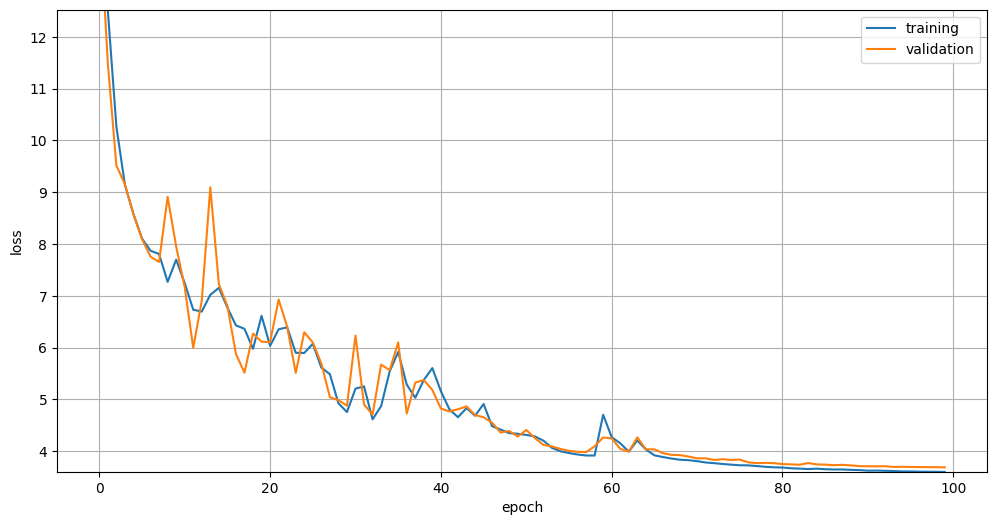

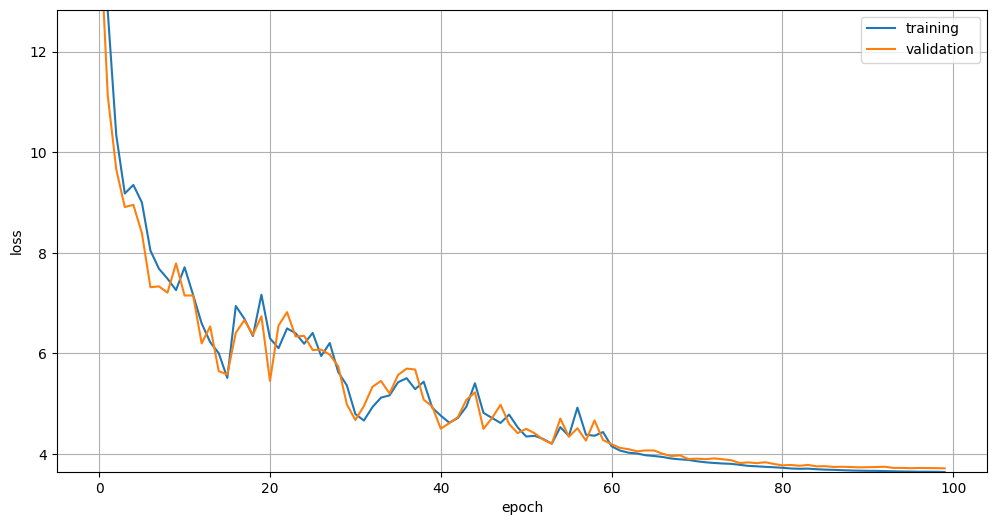

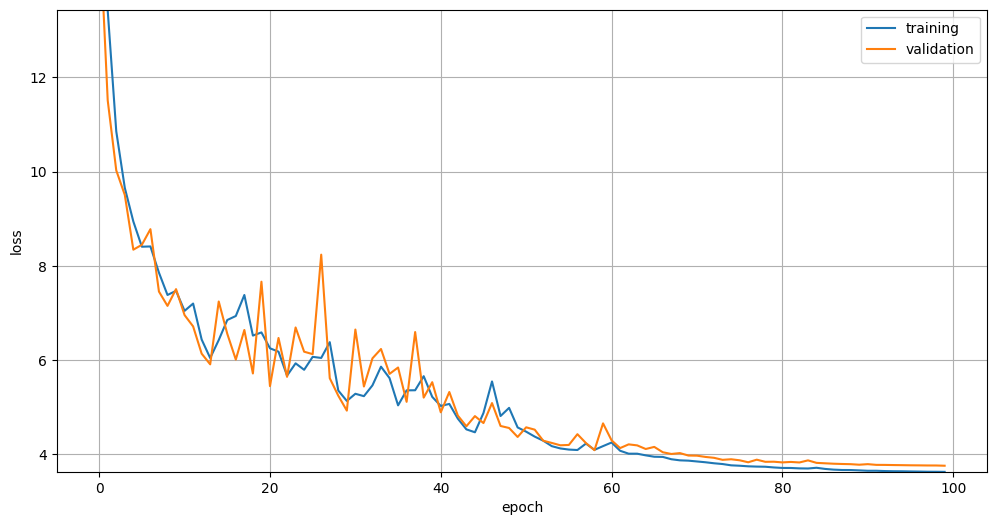

In [8]:
ensemble.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    batch_size=batch_size,
    scheduler_type="cosine",
    save_model=True,
)

In [18]:
# grid
i_grid = 0
obs_pred = grid_preds[i_grid]
obs_cosmo = {str(param): value for param, value in zip(params, grid_cosmos[i_grid])}

In [19]:
# buzzard
i_buzzard = 0
obs_pred = np.squeeze(file_dict[f"mocks/pred/Buzzard_{i_buzzard}"])
obs_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

26-01-23 05:26:59 likelihood_f INF   Sampling individual posteriors from 3 flows 
26-01-23 05:26:59 likelihood_f INF   Sampling posterior from flow 1/3 
26-01-23 05:26:59 likelihood_f INF   Sampling the posterior from a single observation 
26-01-23 05:26:59      mcmc.py INF   Initial values in prior: 51.6% 
26-01-23 05:26:59      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:26<00:00, 38.09it/s]

26-01-23 05:27:25      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:26<00:00, 38.13it/s]

26-01-23 05:27:51      mcmc.py INF   MAP parameters: {'Om': 0.289, 's8': 0.842, 'w0': -0.962, 'Aia': 0.282, 'n_Aia': 3.84, 'bta': 1.928} 
26-01-23 05:27:51      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/400000_steps_likelihood_test_ensemble_flow_0/likelihood_flow/chain_flow_0.npy 
26-01-23 05:27:51 likelihood_f INF   Sampling posterior from flow 2/3 
26-01-23 05:27:51 likelihood_f INF   Sampling the posterior from a single observation 
26-01-23 05:27:51      mcmc.py INF   Initial values in prior: 47.1% 
26-01-23 05:27:51      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


...

  0%|          | 0/21 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

26-01-23 05:29:49  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/models/contours.png 


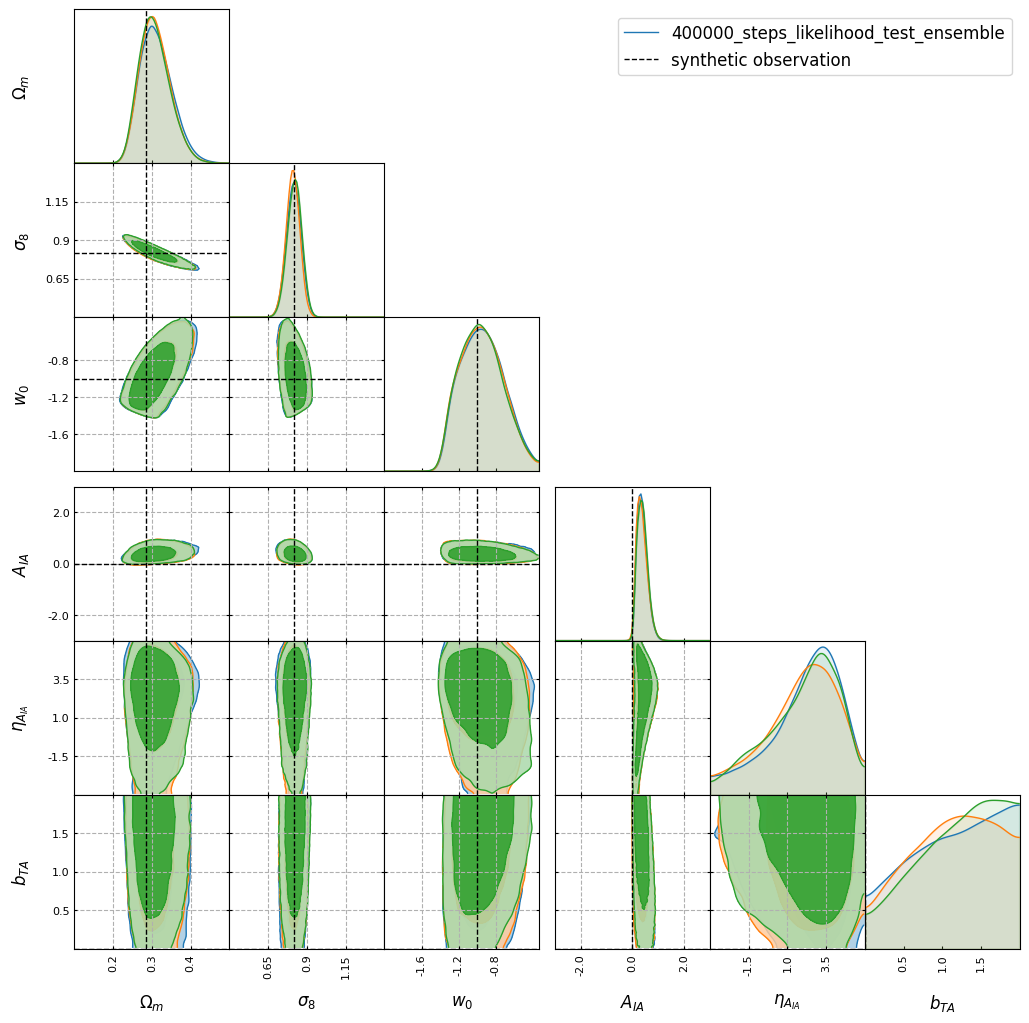

In [20]:
individual_samples = ensemble.sample_posterior(
    obs_pred,
    n_walkers=1024,
    n_burnin_steps=1000,
    n_samples=1024*1000,
    method="individual",
)

ensemble.plot_contours(
    individual_samples,
    obs_point=obs_cosmo,
)

26-01-23 05:34:33      mcmc.py INF   Initial values in prior: 47.5% 
26-01-23 05:34:33      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [01:24<00:00, 11.82it/s]

26-01-23 05:35:57      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [01:41<00:00,  9.90it/s]

26-01-23 05:37:38      mcmc.py INF   MAP parameters: {'Om': 0.297, 's8': 0.832, 'w0': -0.957, 'Aia': 0.311, 'n_Aia': 4.139, 'bta': 1.893} 
26-01-23 05:37:39      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/models/chain.npy 



/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

26-01-23 05:37:43  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/models/contours.png 


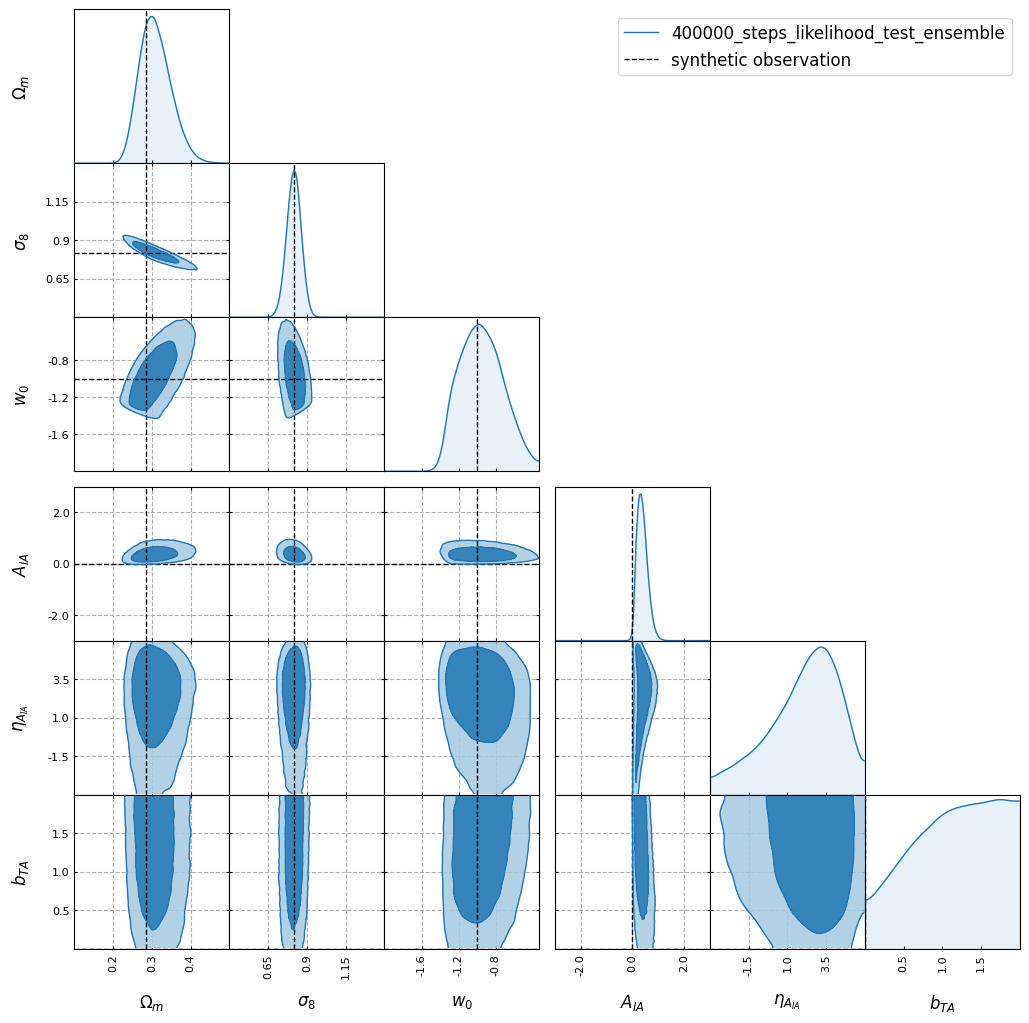

In [21]:
ensemble_samples = ensemble.sample_posterior(
    obs_pred,
    n_walkers=1024,
    n_burnin_steps=1000,
    n_samples=1024*1000,
)

ensemble.plot_contours(
    ensemble_samples,
    obs_point=obs_cosmo,
)